# Imports

In [1]:
import os
import json
import torch
import numpy as np
from datetime import datetime
import itertools

import sys
sys.path.append("../src")

from sian.experiment.exp_sampleSizeSweep import RealWorldDatasetExperiment
from sian.experiment.experiment_mixins import DatasetSetupMixin
from sian.utils import gettimestamp

from dataclasses import dataclass

# Setting Up Common Configurations

In [6]:
@dataclass
class Common_Configs:
    DEBUGGING_FLAG = True
#     data_base_path = "../final_experiments/sep2025_more_complex_synthetic_sweeps/data/"
    data_base_path = "../data/"

# Setting Up the Hyperparameters for the Demo

In [10]:
@dataclass
class HYPERPARAMETERS:
    dataset_preproc_pairs = [
#         ("UCI_275_bike_sharing_dataset", None),
#         ("UCI_2_adults_dataset", None),
        ("UCI_31_tree_cover_type_dataset", None)
    ]
    DEBUGGING_FLAG = Common_Configs.DEBUGGING_FLAG

    masked_combinations = [(True, False)]
    use_mnist_scaling = ["smooth"]
    BS_list = [32]
    LR_list = [5e-3]
    STEP_list = [1024 * 1024 * 1]
    if DEBUGGING_FLAG:
        STEP_list = [10]

    MAX_K_list = [1, 2, 3, 5]
    MAX_K_list = [2]
    FIS_style_list = ["batchwise", "layerwise"]
    explainer_score_types = ["arch"]

    tau_dict_list = [
        {1: 1.0, 2: 0.5, 3: 0.33, 4: 0.25, 5: 0.20},
    ]
    theta_dict_list = [
        {1: 0.5, 2: 0.5, 3: 0.5, 4: 0.5, 5: 0.5},
    ]
    rounds_dict_list = [
        {1: 100, 2: 100, 3: 100, 4: 100, 5: 100},
    ]
    if DEBUGGING_FLAG:
        rounds_dict_list = [{1: 3, 2: 3, 3: 3, 4: 3, 5: 3}]

    inters_dict_list = [
#         {1: 10, 2: 10, 3: 10, 4: 10, 5: 10},
        {1: 5, 2: 5, 3: 5, 4: 5, 5: 5},
    ]

    TARGET_SAMPLE_SIZES = [100, 800, "get_N"] if not DEBUGGING_FLAG else [100, "get_N"]
    TARGET_SAMPLE_SIZES = [100, "get_N"]
    TARGET_SAMPLE_SIZES = ["get_N"]

    ALL_SEEDS = [0, 1, 2] if not DEBUGGING_FLAG else [0]
    ALL_SEEDS = [0]

# Create a Single Experiment Configuration

In [11]:
def build_single_experiment_config():
    (is_masked_mlp, is_masked_sian), use_mnist, BS, LR, STEP, FIS_style, explainer_score_type = next(
        itertools.product(
            HYPERPARAMETERS.masked_combinations,
            HYPERPARAMETERS.use_mnist_scaling,
            HYPERPARAMETERS.BS_list,
            HYPERPARAMETERS.LR_list,
            HYPERPARAMETERS.STEP_list,
            HYPERPARAMETERS.FIS_style_list,
            HYPERPARAMETERS.explainer_score_types,
        )
    )

    dataset_str, preproc_owner = HYPERPARAMETERS.dataset_preproc_pairs[0]
    master_seed = HYPERPARAMETERS.ALL_SEEDS[0]
    MAX_K = HYPERPARAMETERS.MAX_K_list[0]

    hyperparameter_combo_list = []
    arange_K = list(range(1, MAX_K + 1))

    if FIS_style == "layerwise":
        for tau_dict, theta_dict in itertools.product(
            HYPERPARAMETERS.tau_dict_list, HYPERPARAMETERS.theta_dict_list
        ):
            if all(k in tau_dict for k in arange_K) and all(k in theta_dict for k in arange_K):
                hyperparam_str = (
                    f"t{''.join(f'{tau_dict[k]:.2f}'[:4] for k in arange_K)}"
                    f"_th{''.join(f'{theta_dict[k]:.2f}'[:4] for k in arange_K)}"
                )
                hyperparameter_combo_list.append({
                    "FIS_style": FIS_style,
                    "MAX_K": MAX_K,
                    "explainer_score_type": explainer_score_type,
                    "tau_thresholds": tau_dict,
                    "theta_thresholds": theta_dict,
                    "number_of_rounds": None,
                    "inters_per_round": None,
                    "hyperparam_str": hyperparam_str,
                })

    elif FIS_style == "batchwise":
        for tau_dict, rounds_dict, inters_dict in itertools.product(
            HYPERPARAMETERS.tau_dict_list, HYPERPARAMETERS.rounds_dict_list, HYPERPARAMETERS.inters_dict_list
        ):
            if (all(k in tau_dict for k in arange_K) and
                all(k in rounds_dict for k in arange_K) and
                all(k in inters_dict for k in arange_K)):

                number_of_rounds = rounds_dict[MAX_K]
                inters_per_round = inters_dict[MAX_K]
                hyperparam_str = (
                    f"t{''.join(f'{tau_dict[k]:.2f}'[:4] for k in arange_K)}"
                    f"_r{number_of_rounds}_i{inters_per_round}"
                )
                hyperparameter_combo_list.append({
                    "FIS_style": FIS_style,
                    "MAX_K": MAX_K,
                    "explainer_score_type": explainer_score_type,
                    "tau_thresholds": tau_dict,
                    "number_of_rounds": number_of_rounds,
                    "inters_per_round": inters_per_round,
                    "theta_thresholds": None,
                    "hyperparam_str": hyperparam_str,
                })
    else:
        raise ValueError(f"Unsupported FIS_style: {FIS_style}")

    if not hyperparameter_combo_list:
        raise RuntimeError("No valid FIS hyper-parameter combo was built!")

    full_experiment_details = {
        "data_base_path": Common_Configs.data_base_path,
        "dataset_str": dataset_str,
        "preproc_owner": preproc_owner,
        "is_masked_mlp": is_masked_mlp,
        "is_masked_sian": is_masked_sian,
        "use_mnist_scaling": use_mnist,
        "BS": BS,
        "LR": LR,
        "STEP": STEP,
        "target_sample_sizes": HYPERPARAMETERS.TARGET_SAMPLE_SIZES,
        "hyperparameter_combo_list": hyperparameter_combo_list,
        "master_seed": master_seed,
        "type_of_experiment": "real_world_dataset_experiment",
    }

    return full_experiment_details

configuration = build_single_experiment_config()
configuration

{'data_base_path': '../data/',
 'dataset_str': 'UCI_31_tree_cover_type_dataset',
 'preproc_owner': None,
 'is_masked_mlp': True,
 'is_masked_sian': False,
 'use_mnist_scaling': 'smooth',
 'BS': 32,
 'LR': 0.005,
 'STEP': 10,
 'target_sample_sizes': ['get_N'],
 'hyperparameter_combo_list': [{'FIS_style': 'batchwise',
   'MAX_K': 2,
   'explainer_score_type': 'arch',
   'tau_thresholds': {1: 1.0, 2: 0.5, 3: 0.33, 4: 0.25, 5: 0.2},
   'number_of_rounds': 3,
   'inters_per_round': 5,
   'theta_thresholds': None,
   'hyperparam_str': 't1.000.50_r3_i5'}],
 'master_seed': 0,
 'type_of_experiment': 'real_world_dataset_experiment'}

# Run SIAN Demo

In [14]:
# def run_sian_demo(configuration):
#     print("\n=== Real-World Dataset Demo ===\n")

#     timestamp = gettimestamp()
#     exp_folder = f"results/{timestamp}_demo_realworld/"
#     os.makedirs(exp_folder, exist_ok=True)
#     print(f"Results will be stored in: {exp_folder}")

#     dataset_mixin = DatasetSetupMixin()
#     dataset_obj, _, _, _ = dataset_mixin.setup_dataset(configuration)
#     full_N = dataset_obj.get_N()
#     print(f"Full training set size (get_N): {full_N}")

#     experiment = RealWorldDatasetExperiment()
#     experiment.run_realworld_experiment(configuration, exp_folder)

#     print("\nDemo finished!")

# run_sian_demo(configuration)


=== Real-World Dataset Demo ===

Results will be stored in: results/20251113_162239_demo_realworld/
preproc_owner=None, so using default preproc_owner=InstaSHAP2025
header_path ../data/UCI_31_tree_cover_type_dataset/data_header.json
header_dict {'Preprocessed Datetime': '20250815_154157', 'dataset_id': 'UCI_31_tree_cover_type_dataset', 'preproc_owner': 'InstaSHAP2025', 'load_dataset_path': '../../data/', 'save_dataset_path': '../../data/UCI_31_tree_cover_type_dataset/', 'is_test_split_shuffled': True, 'shuffle_test_split_seed': 0, 'trainval_portion': 0.8}
Loading existing dataset from ../data/UCI_31_tree_cover_type_dataset/
trnval_shuffle_seed 0
self.trnval_shuffle_seed 0
M_NUM 464809 M_TRNVAL_N 464809 M_TRN_N 325366
Full training set size (get_N): 464809
Using model_init_seed=0 and data_seed=0
preproc_owner=None, so using default preproc_owner=InstaSHAP2025
header_path ../data/UCI_31_tree_cover_type_dataset/data_header.json
header_dict {'Preprocessed Datetime': '20250815_154157', 'da

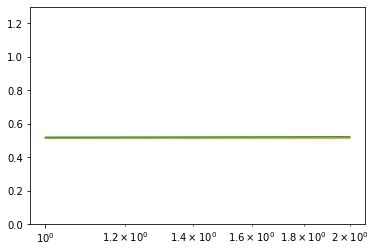

WARNING - CLASSIFICATION MASKED PLOTS NOT SHOWN
2 evaluation {'trn_metric': 0.46343458540396465, 'val_metric': 0.4677865977502305, 'tst_metric': 0.4729356605796086}
Steps without improvement = 1
ROC-AUC for train and val: 0.4678, 0.4678


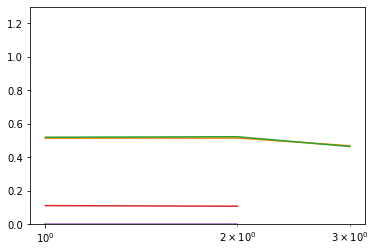

WARNING - CLASSIFICATION MASKED PLOTS NOT SHOWN
Adagrad()
Starting to mask ^_^
4 evaluation {'trn_metric': 0.6647101680158777, 'val_metric': 0.6673134027280437, 'tst_metric': 0.6636616588172393}
Steps without improvement = 0
ROC-AUC for train and val: 0.6673, 0.5386


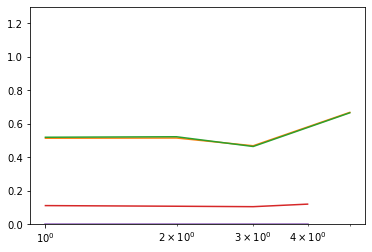

WARNING - CLASSIFICATION MASKED PLOTS NOT SHOWN
8 evaluation {'trn_metric': 0.6672420762544992, 'val_metric': 0.6618916743705311, 'tst_metric': 0.667448709357814}
Steps without improvement = 0
ROC-AUC for train and val: 0.6619, 0.6051


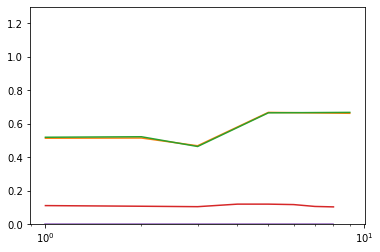

WARNING - CLASSIFICATION MASKED PLOTS NOT SHOWN


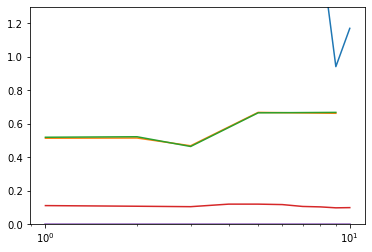

epoch 1'
--- 60.311 seconds in epoch ---
FULLY TRAINED USING 60.311180114746094 seconds
Test Accuracy:  0.4870
Test Precision: 0.0696
Test Recall:    0.1429
Test F1 Score:  0.0936
Test ROC AUC:   0.6294
Test AUPRC:     0.1895
Inside function return_score_type_name is_masked_mlp True
FID masking style masking_based
results/20251113_162239_demo_realworld/20251113_162354_ESTarch_K2_N464809_tau1.0_0.5_0.33_0.25_0.2_rounds3_inters_per_round5
fid_mode new_arch_inter_var_score
fid_mode_index 2
nr 0
tuple_inc_output_logits torch.Size([13, 139443, 7])
archipelago_tensor (12, 2, 139443, 7)
semitruth torch.Size([139443, 7])


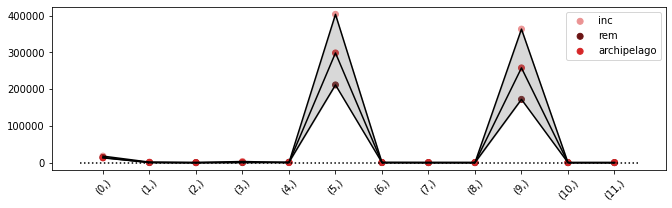

new_selections [(5,), (9,), (0,), (3,), (1,)]
selections [(5,), (9,), (0,), (3,), (1,)]
nn 1 tau 0.5
new_cands [(0, 5), (1, 5), (2, 5), (3, 5), (4, 5), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (0, 9), (1, 9), (2, 9), (3, 9), (4, 9), (6, 9), (7, 9), (8, 9), (9, 10), (9, 11), (0, 1), (0, 2), (0, 3), (0, 4), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (1, 3), (2, 3), (3, 4), (3, 6), (3, 7), (3, 8), (3, 10), (3, 11), (1, 2), (1, 4), (1, 6), (1, 7), (1, 8), (1, 10), (1, 11)]
candidates [(2,), (4,), (6,), (7,), (8,), (10,), (11,), (0, 5), (1, 5), (2, 5), (3, 5), (4, 5), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (0, 9), (1, 9), (2, 9), (3, 9), (4, 9), (6, 9), (7, 9), (8, 9), (9, 10), (9, 11), (0, 1), (0, 2), (0, 3), (0, 4), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (1, 3), (2, 3), (3, 4), (3, 6), (3, 7), (3, 8), (3, 10), (3, 11), (1, 2), (1, 4), (1, 6), (1, 7), (1, 8), (1, 10), (1, 11)]
2.320108652114868 seconds
nr 1
tuple_inc_output_logits torch.Size([58, 139443, 7])
archipela

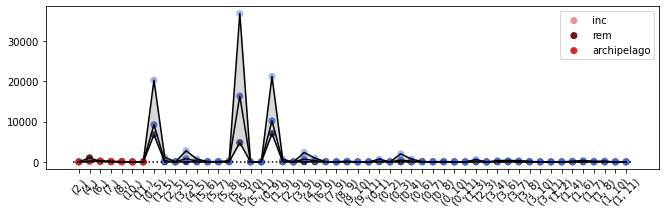

new_selections [(5, 9), (0, 9), (0, 5), (3, 5), (3, 9)]
selections [(5,), (9,), (0,), (3,), (1,), (5, 9), (0, 9), (0, 5), (3, 5), (3, 9)]
nn 1 tau 0.5
new_cands [(0, 5), (1, 5), (2, 5), (3, 5), (4, 5), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (0, 9), (1, 9), (2, 9), (3, 9), (4, 9), (6, 9), (7, 9), (8, 9), (9, 10), (9, 11), (0, 1), (0, 2), (0, 3), (0, 4), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (1, 3), (2, 3), (3, 4), (3, 6), (3, 7), (3, 8), (3, 10), (3, 11), (1, 2), (1, 4), (1, 6), (1, 7), (1, 8), (1, 10), (1, 11)]
candidates [(2,), (4,), (6,), (7,), (8,), (10,), (11,), (1, 5), (2, 5), (4, 5), (5, 6), (5, 7), (5, 8), (5, 10), (5, 11), (1, 9), (2, 9), (4, 9), (6, 9), (7, 9), (8, 9), (9, 10), (9, 11), (0, 1), (0, 2), (0, 3), (0, 4), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (1, 3), (2, 3), (3, 4), (3, 6), (3, 7), (3, 8), (3, 10), (3, 11), (1, 2), (1, 4), (1, 6), (1, 7), (1, 8), (1, 10), (1, 11)]
11.456058979034424 seconds
nr 2
tuple_inc_output_logits torch.Size([53, 139443, 7]

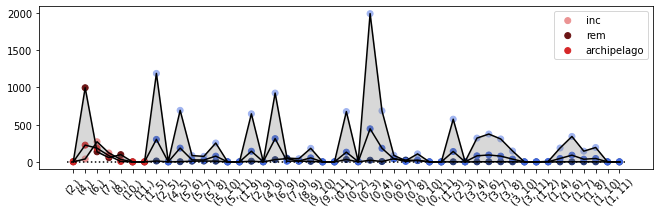

new_selections [(0, 3), (4, 9), (1, 5), (4,), (4, 5)]
selections [(5,), (9,), (0,), (3,), (1,), (5, 9), (0, 9), (0, 5), (3, 5), (3, 9), (0, 3), (4, 9), (1, 5), (4,), (4, 5)]
nn 1 tau 0.5
new_cands [(0, 5), (1, 5), (2, 5), (3, 5), (4, 5), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (0, 9), (1, 9), (2, 9), (3, 9), (4, 9), (6, 9), (7, 9), (8, 9), (9, 10), (9, 11), (0, 1), (0, 2), (0, 3), (0, 4), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (1, 3), (2, 3), (3, 4), (3, 6), (3, 7), (3, 8), (3, 10), (3, 11), (1, 2), (1, 4), (1, 6), (1, 7), (1, 8), (1, 10), (1, 11), (2, 4), (4, 6), (4, 7), (4, 8), (4, 10), (4, 11)]
candidates [(2,), (6,), (7,), (8,), (10,), (11,), (2, 5), (5, 6), (5, 7), (5, 8), (5, 10), (5, 11), (1, 9), (2, 9), (6, 9), (7, 9), (8, 9), (9, 10), (9, 11), (0, 1), (0, 2), (0, 4), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (1, 3), (2, 3), (3, 4), (3, 6), (3, 7), (3, 8), (3, 10), (3, 11), (1, 2), (1, 4), (1, 6), (1, 7), (1, 8), (1, 10), (1, 11), (2, 4), (4, 6), (4, 7), (4, 8), (4

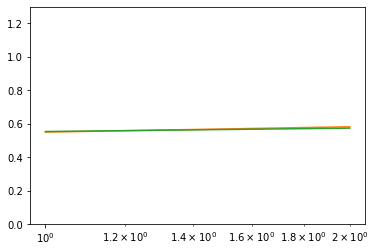

2 evaluation {'trn_metric': 0.6163348077288384, 'val_metric': 0.6230220209412106, 'tst_metric': 0.6220468547312964}
Steps without improvement = 0
ROC-AUC for train and val: 0.6230, 0.6230


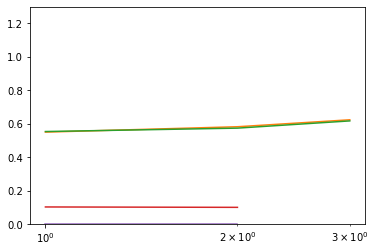

4 evaluation {'trn_metric': 0.6815676478855589, 'val_metric': 0.6769139686238738, 'tst_metric': 0.6848244099023403}
Steps without improvement = 0
ROC-AUC for train and val: 0.6769, 0.6769


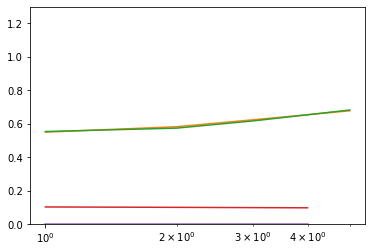

8 evaluation {'trn_metric': 0.745888288068118, 'val_metric': 0.7468149081596632, 'tst_metric': 0.7470358395280137}
Steps without improvement = 0
ROC-AUC for train and val: 0.7468, 0.7468


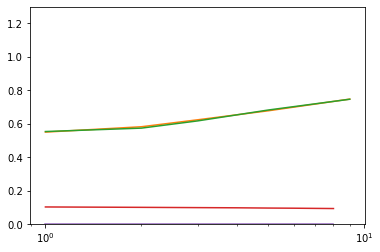

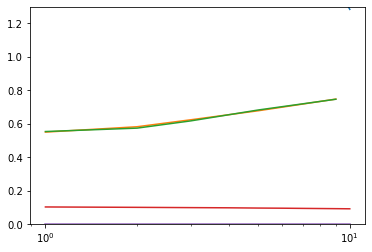

epoch 1'
--- 21.264 seconds in epoch ---
FULLY TRAINED USING 21.264788389205933 seconds
Test Accuracy:  0.4925
Test Precision: 0.1443
Test Recall:    0.1454
Test F1 Score:  0.1008
Test ROC AUC:   0.7438
Test AUPRC:     0.3008
Using device: cuda
GPU Name: NVIDIA GeForce GTX 1080
CUDA Version: 11.7
Using device: cuda
GPU Name: NVIDIA GeForce GTX 1080
CUDA Version: 11.7
JSON results saved successfully
Full pipeline saved: results/20251113_162239_demo_realworld/20251113_162439_N464809_SIAN_K2_FISbatchwise_hyp0.json

Demo finished!


In [13]:

print("\n=== Real-World Dataset Demo ===\n")

timestamp = gettimestamp()
exp_folder = f"results/{timestamp}_demo_realworld/"
os.makedirs(exp_folder, exist_ok=True)
print(f"Results will be stored in: {exp_folder}")

dataset_mixin = DatasetSetupMixin()
dataset_obj, _, _, _ = dataset_mixin.setup_dataset(configuration)
full_N = dataset_obj.get_N()
print(f"Full training set size (get_N): {full_N}")

experiment = RealWorldDatasetExperiment()
experiment.run_realworld_experiment(configuration, exp_folder)

print("\nDemo finished!")